In [1]:
import matplotlib.pyplot as plt
import seaborn as sns  # for scatter plots.
import numpy as np
import pandas as pd  # used to count cluster sizes
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
cancer = load_breast_cancer()
X = cancer.data
labels_true = cancer.target
feature_names = cancer.feature_names


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
pca = PCA(n_components=2)
xp_capabilitiess = pca.fit_transform(X_scaled)

In [5]:
linkage_methods = ['single', 'complete', 'average', 'ward']
for linkage_method in linkage_methods:
    Z = linkage(xp_capabilitiess, method=linkage_method)

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [62.5, 62.5, 92.5, 92.5],
  [32.5, 32.5, 77.5, 77.5],
  [10.0, 10.0, 55.0, 55.0],
  [125.0, 125.0, 135.0, 135.0],
  [145.0, 145.0, 155.0, 155.0],
  [130.0, 130.0, 150.0, 150.0],
  [115.0, 115.0, 140.0, 140.0],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [195.0, 195.0, 205.0, 205.0],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [200.0, 200.0, 222.5, 222.5],
  [172.5, 172.5, 211.25, 211.25],
  [127.5, 127.5, 191.875, 191.875],
  [245.0, 245.0, 255.0, 255.0],
  [265.0, 265.0, 275.0, 275.0],
  [250.0, 250.0, 270.0, 270.0],
  [285.0, 285.0, 295.0, 295.0],
  [260.0, 260.0, 290.0, 290.0],
  [159.6875, 159.6875, 275.0, 275.0],
  [32.5, 32.5, 217.34375, 217.34375],
  [335.0, 335.0, 345.0, 345.0],
  [325.0, 325.0, 340.0, 340.0],
  [315.0, 315.0, 3

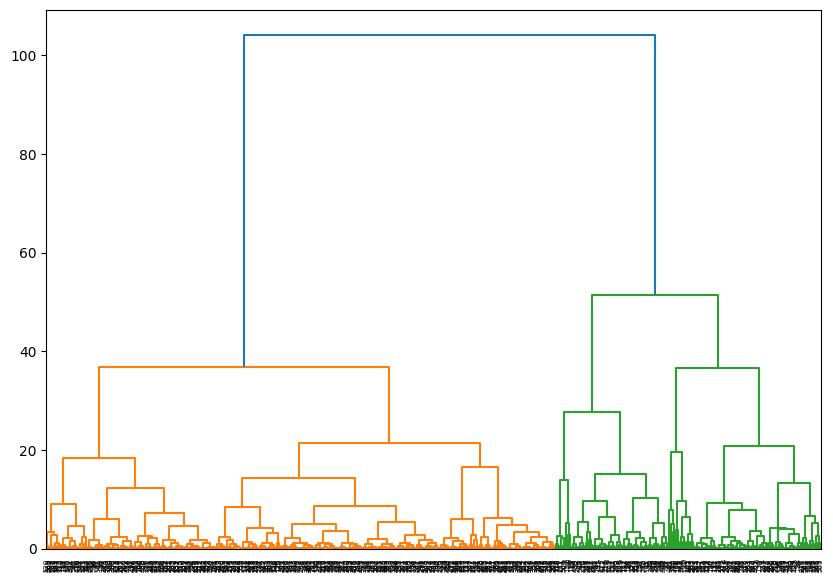

In [6]:
plt.figure(figsize=(10, 7))
dendrogram(Z)

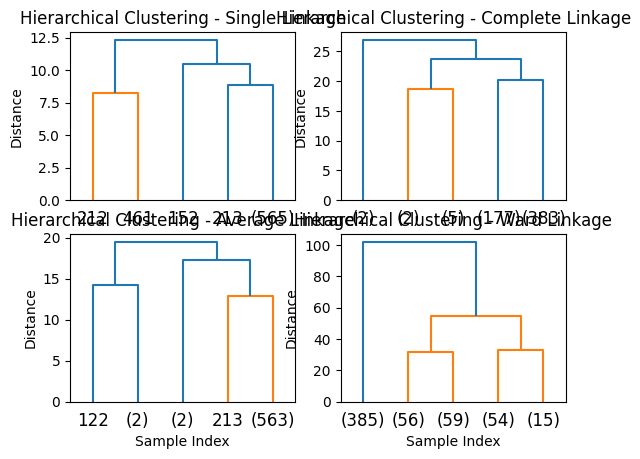

In [7]:
for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, truncate_mode="lastp", p=5)
    plt.title(f"Hierarchical Clustering - {method.capitalize()} Linkage")
    plt.xlabel("Sample Index")
    plt.ylabel("Distance")

In [8]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [9]:
for method in linkage_methods:
    Z = linkage(X_scaled, method=method)
    clusters = fcluster(Z, t=2, criterion='maxclust')  # Since we know dataset h...
    print(f"\nCluster assignments using {method} linkage:")
    print(pd.Series(clusters).value_counts())



Cluster assignments using single linkage:
2    567
1      2
Name: count, dtype: int64

Cluster assignments using complete linkage:
2    567
1      2
Name: count, dtype: int64

Cluster assignments using average linkage:
2    566
1      3
Name: count, dtype: int64

Cluster assignments using ward linkage:
1    385
2    184
Name: count, dtype: int64


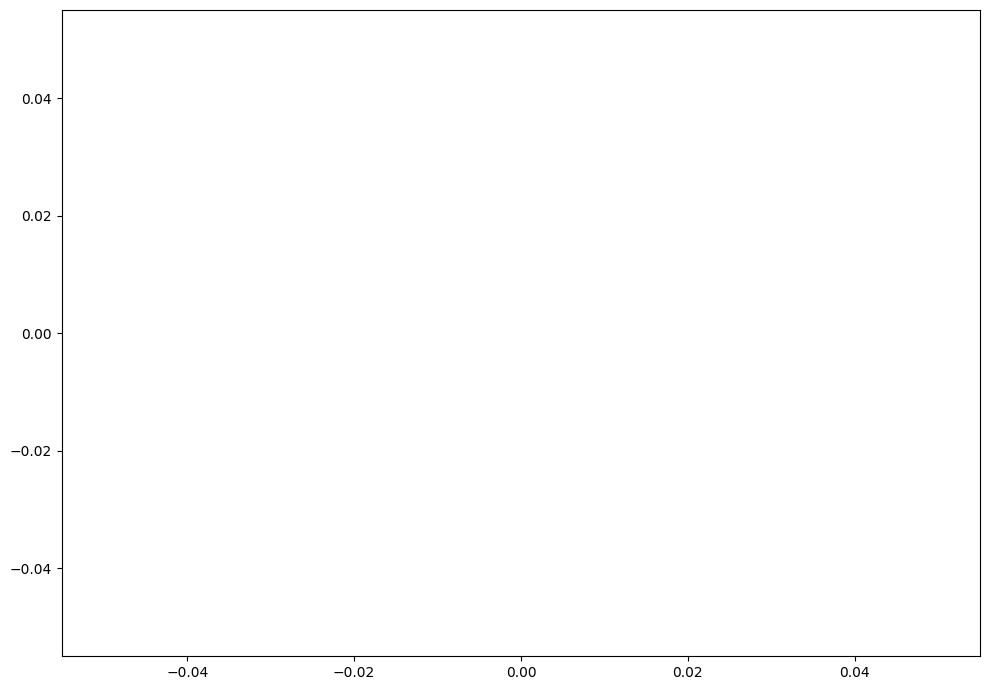


Cluster assignments using single linkage:
2    567
1      2
Name: count, dtype: int64


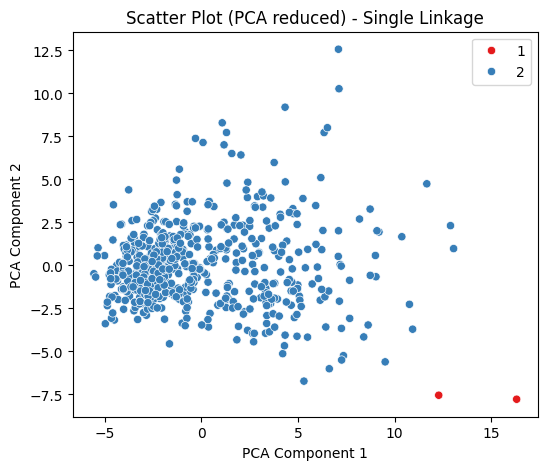


Cluster assignments using complete linkage:
2    567
1      2
Name: count, dtype: int64


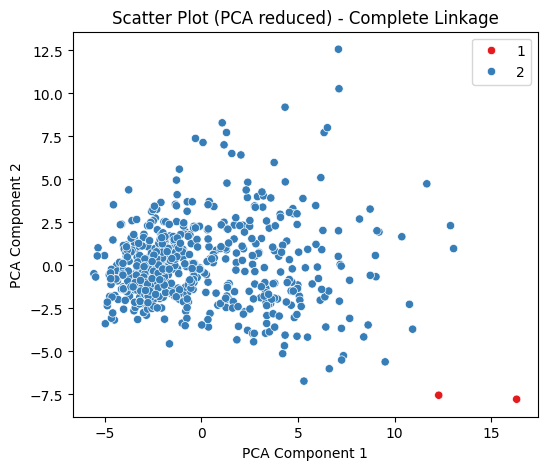


Cluster assignments using average linkage:
2    566
1      3
Name: count, dtype: int64


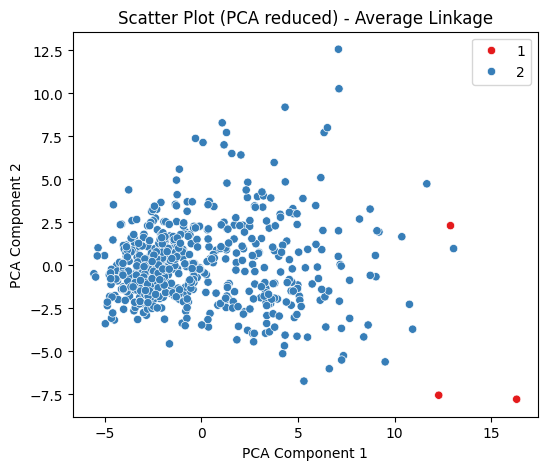


Cluster assignments using ward linkage:
1    385
2    184
Name: count, dtype: int64


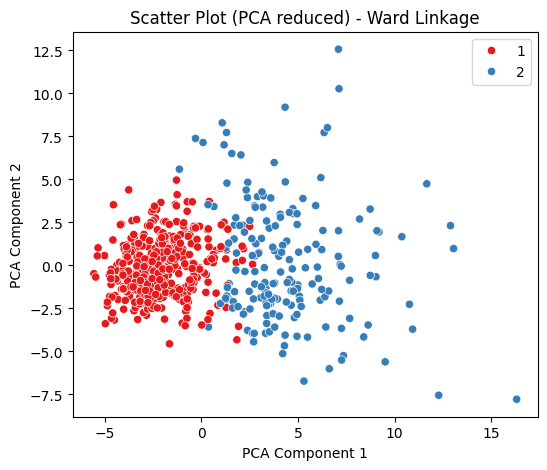

In [10]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=xp_capabilitiess[:,0])

plt.tight_layout()
plt.show()

# Cluster assignments for each linkage method
for method in linkage_methods:
    Z = linkage(X_scaled, method=method)
    clusters = fcluster(Z, t=2, criterion='maxclust')  # Since we know dataset h...
    print(f"\nCluster assignments using {method} linkage:")
    print(pd.Series(clusters).value_counts())

    # Plot scatter with cluster colors (using PCA reduced data)
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=xp_capabilitiess[:, 0], y=xp_capabilitiess[:, 1], hue=clusters, palette="Set1")
    plt.title(f"Scatter Plot (PCA reduced) - {method.capitalize()} Linkage")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()